# Baseline Prediksi Emisi Karbon (Skenario A)

Notebook ini membangun baseline model untuk prediksi emisi karbon menggunakan data time-series lingkungan dari stasiun AmeriFlux. Dua model yang dibandingkan: **RandomForestRegressor** dan **XGBoostRegressor**.

- Preprocessing dan mapping kolom sesuai skema IoT
- Validasi time-series (split kronologis)
- Evaluasi: MAE, RMSE, R2
- Visualisasi feature importance

---

## 1. Import Library dan Definisikan Fungsi Utilitas

Impor library yang dibutuhkan dan buat fungsi utilitas untuk evaluasi dan visualisasi.

In [33]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Fungsi utilitas evaluasi

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred) 
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Fungsi visualisasi feature importance

def plot_feature_importance(model, feature_names, title='Feature Importance'):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.get_booster().get_score(importance_type='weight')
        importances = np.array([importances.get(f, 0) for f in feature_names])
    
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False)
    plt.figure(figsize=(10,5))
    sns.barplot(x='Importance', y='Feature', data=fi_df)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 2. Load dan Inspeksi Dataset

Muat data dari file CSV lokal dan tampilkan beberapa baris awal serta info struktur data.

In [ ]:
# Path file CSV
csv_path = r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne1_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne1_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'

# Load data
raw_df = pd.read_csv(csv_path)

# Tampilkan beberapa baris awal dan info
print('Jumlah baris dan kolom:', raw_df.shape)
display(raw_df.head())
raw_df.info()

Jumlah baris dan kolom: (210384, 241)


,TIMESTAMP_START,TIMESTAMP_END,TA_F_MDS,TA_F_MDS_QC,TA_ERA,TA_F,TA_F_QC,SW_IN_POT,SW_IN_F_MDS,SW_IN_F_MDS_QC,...,GPP_DT_CUT_USTAR50,GPP_DT_CUT_MEAN,GPP_DT_CUT_SE,GPP_DT_CUT_05,GPP_DT_CUT_16,GPP_DT_CUT_25,GPP_DT_CUT_50,GPP_DT_CUT_75,GPP_DT_CUT_84,GPP_DT_CUT_95
0,200101010000,200101010100,-9999.0,-9999,-18.889,-18.889,2,0.0,-9999.0,-9999,...,-9999.0,-9999.0,0.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
1,200101010100,200101010200,-9999.0,-9999,-19.966,-19.966,2,0.0,-9999.0,-9999,...,-9999.0,-9999.0,0.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
2,200101010200,200101010300,-9999.0,-9999,-20.819,-20.819,2,0.0,-9999.0,-9999,...,-9999.0,-9999.0,0.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3,200101010300,200101010400,-9999.0,-9999,-20.854,-20.854,2,0.0,-9999.0,-9999,...,-9999.0,-9999.0,0.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
4,200101010400,200101010500,-9999.0,-9999,-23.524,-23.524,2,0.0,-9999.0,-9999,...,-9999.0,-9999.0,0.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0


<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Columns: 241 entries, TIMESTAMP_START to GPP_DT_CUT_95
dtypes: float64(171), int64(70)
memory usage: 386.8 MB


## 3. Preprocessing: Tangani Missing Value & Mapping Kolom

Ganti -9999 dengan NaN dan lakukan mapping nama kolom sesuai instruksi.

In [35]:
# Salin data untuk preprocessing

df = raw_df.copy()

# Ganti -9999 dengan NaN
for col in df.columns:
    df[col] = df[col].replace(-9999, np.nan)

# Mapping kolom sesuai instruksi
col_mapping = {}
for col in df.columns:
    if col == 'TIMESTAMP_START':
        col_mapping[col] = 'reading_time'
    elif col.startswith('TA_'):
        col_mapping[col] = 'air_temperature_sensor_' + col.split('_', 1)[-1] if '_' in col else 'air_temperature_sensor'
    elif col == 'RH':
        col_mapping[col] = 'air_humidity_sensor'
    elif col.startswith('TS_'):
        col_mapping[col] = 'soil_temperature_' + col.split('_', 1)[-1] if '_' in col else 'soil_temperature'
    elif col.startswith('SWC_'):
        col_mapping[col] = 'soil_moisture_' + col.split('_', 1)[-1] if '_' in col else 'soil_moisture'
    elif col == 'NEE_VUT_REF':
        col_mapping[col] = 'carbon_flux'
    else:
        col_mapping[col] = col

df = df.rename(columns=col_mapping)

display(df.head())

,reading_time,TIMESTAMP_END,air_temperature_sensor_F_MDS,air_temperature_sensor_F_MDS_QC,air_temperature_sensor_ERA,air_temperature_sensor_F,air_temperature_sensor_F_QC,SW_IN_POT,SW_IN_F_MDS,SW_IN_F_MDS_QC,...,GPP_DT_CUT_USTAR50,GPP_DT_CUT_MEAN,GPP_DT_CUT_SE,GPP_DT_CUT_05,GPP_DT_CUT_16,GPP_DT_CUT_25,GPP_DT_CUT_50,GPP_DT_CUT_75,GPP_DT_CUT_84,GPP_DT_CUT_95
0,200101010000,200101010100,NaN,NaN,-18.889,-18.889,2,0.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200101010100,200101010200,NaN,NaN,-19.966,-19.966,2,0.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200101010200,200101010300,NaN,NaN,-20.819,-20.819,2,0.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,200101010300,200101010400,NaN,NaN,-20.854,-20.854,2,0.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200101010400,200101010500,NaN,NaN,-23.524,-23.524,2,0.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Feature Engineering: Ekstraksi Fitur Waktu

Ekstrak fitur hour, day, dan month dari kolom reading_time.

In [36]:
# Pastikan reading_time bertipe string dan parse ke datetime

df['reading_time'] = pd.to_datetime(df['reading_time'], errors='coerce', format='%Y%m%d%H%M')

df['hour'] = df['reading_time'].dt.hour

df['day'] = df['reading_time'].dt.day

df['month'] = df['reading_time'].dt.month

display(df[['reading_time', 'hour', 'day', 'month']].head())

,reading_time,hour,day,month
0,2001-01-01 00:00:00,0,1,1
1,2001-01-01 01:00:00,1,1,1
2,2001-01-01 02:00:00,2,1,1
3,2001-01-01 03:00:00,3,1,1
4,2001-01-01 04:00:00,4,1,1


## 5. Bersihkan Data: Drop Baris dengan Nilai Hilang pada Fitur Utama/Target

Drop baris yang memiliki missing value pada carbon_flux atau fitur utama.

In [37]:
# Deteksi dan hapus seluruh kolom _QC (hindari feature leakage)
qc_cols = [col for col in df.columns if '_QC' in col]
if qc_cols:
    print(f'Jumlah kolom _QC yang dihapus: {len(qc_cols)}')
    print('Contoh kolom yang dihapus:', qc_cols[:10])
    df = df.drop(columns=qc_cols)
else:
    print('Tidak ada kolom _QC yang ditemukan.')

# Pilih fitur utama dan target (setelah kolom _QC dibersihkan)
main_features = [
    col for col in df.columns if (
        col.startswith('air_temperature_sensor') or
        col == 'air_humidity_sensor' or
        col.startswith('soil_temperature') or
        col.startswith('soil_moisture')
    )
]
time_features = ['hour', 'day', 'month']
target = 'carbon_flux'

# Drop baris dengan missing value pada fitur utama atau target
clean_df = df.dropna(subset=main_features + time_features + [target]).reset_index(drop=True)

features = main_features + time_features
print(f'Jumlah data setelah dibersihkan: {clean_df.shape}')
print(f'Jumlah fitur input: {len(features)}')
print('Ada kolom _QC di fitur?', any('_QC' in c for c in features))


Jumlah kolom _QC yang dihapus: 49
Contoh kolom yang dihapus: ['air_temperature_sensor_F_MDS_QC', 'air_temperature_sensor_F_QC', 'SW_IN_F_MDS_QC', 'SW_IN_F_QC', 'LW_IN_F_MDS_QC', 'LW_IN_F_QC', 'LW_IN_JSB_QC', 'LW_IN_JSB_F_QC', 'VPD_F_MDS_QC', 'VPD_F_QC']
Jumlah data setelah dibersihkan: (61, 195)
Jumlah fitur input: 19
Ada kolom _QC di fitur? False


## 6. Time-Series Train-Test Split (80/20 Kronologis)

Pisahkan data secara kronologis: 80% awal untuk train, 20% akhir untuk test.

In [38]:
# Urutkan data berdasarkan waktu
clean_df = clean_df.sort_values('reading_time').reset_index(drop=True)

# Split kronologis 80/20
n = len(clean_df)
n_train = int(0.8 * n)

train_df = clean_df.iloc[:n_train]
test_df = clean_df.iloc[n_train:]

print(f'Train: {train_df.shape}, Test: {test_df.shape}')

Train: (48, 195), Test: (13, 195)


## 7. Latih Model RandomForestRegressor

Latih model RandomForestRegressor dengan fitur dinamis dan waktu.

In [39]:
# Fitur yang digunakan
features = main_features + time_features

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Inisialisasi dan latih RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)


## 8. Latih Model XGBoostRegressor

Latih model XGBoostRegressor dengan fitur yang sama.

In [40]:
# Inisialisasi dan latih XGBoostRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=1, verbosity=0)
xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)


## 9. Evaluasi Model: MAE, RMSE, R2

Evaluasi performa kedua model pada data test.

In [41]:
# Evaluasi kedua model
rf_metrics = evaluate_regression(y_test, y_pred_rf)
xgb_metrics = evaluate_regression(y_test, y_pred_xgb)

# Simpan hasil evaluasi
eval_results = pd.DataFrame([
    {'Model': 'RandomForest', **rf_metrics},
    {'Model': 'XGBoost', **xgb_metrics}
])

# Print metrik secara jelas agar langsung terlihat di output
print('=== Hasil Evaluasi Model (Test Set) ===')
print(
    f"RandomForest -> MAE: {rf_metrics['MAE']:.4f} | "
    f"RMSE: {rf_metrics['RMSE']:.4f} | R2: {rf_metrics['R2']:.4f}"
)
print(
    f"XGBoost      -> MAE: {xgb_metrics['MAE']:.4f} | "
    f"RMSE: {xgb_metrics['RMSE']:.4f} | R2: {xgb_metrics['R2']:.4f}"
)


=== Hasil Evaluasi Model (Test Set) ===
RandomForest -> MAE: 7.7168 | RMSE: 10.0492 | R2: 0.4563
XGBoost      -> MAE: 8.2250 | RMSE: 10.2915 | R2: 0.4297


## 10. Tabel Komparasi Performa Model

Tampilkan tabel perbandingan metrik evaluasi kedua model.

In [42]:
# Tampilkan tabel komparasi tanpa dependensi tambahan
print('\nRingkasan komparasi model:')
print(eval_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))



Ringkasan komparasi model:
       Model    MAE    RMSE     R2
RandomForest 7.7168 10.0492 0.4563
     XGBoost 8.2250 10.2915 0.4297


## 11. Visualisasi Feature Importance Model Terbaik

Visualisasikan feature importance dari model dengan performa terbaik (MAE/RMSE terkecil, R2 terbesar).


Model terbaik: RandomForest (berdasarkan MAE lalu RMSE terkecil)
Verifikasi fitur bersih _QC: True


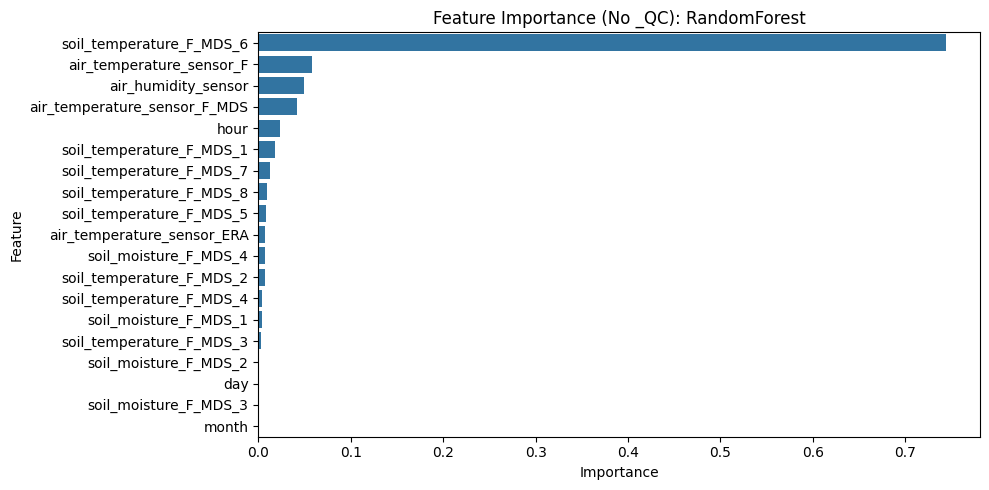

In [43]:
# Pilih model terbaik berdasarkan MAE lalu RMSE terkecil
best_row = eval_results.sort_values(['MAE', 'RMSE', 'R2'], ascending=[True, True, False]).iloc[0]
best_model_name = best_row['Model']

if best_model_name == 'RandomForest':
    best_model = rf_model
else:
    best_model = xgb_model

print(f"\nModel terbaik: {best_model_name} (berdasarkan MAE lalu RMSE terkecil)")
print('Verifikasi fitur bersih _QC:', not any('_QC' in f for f in features))

plot_feature_importance(best_model, features, title=f'Feature Importance (No _QC): {best_model_name}')
